In [1]:
import pandas as pd

In [10]:
df = pd.read_csv('data/full_data.csv')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255640 entries, 0 to 255639
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Date         255640 non-null  object
 1   store        255640 non-null  int64 
 2   product      255640 non-null  int64 
 3   number_sold  255640 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.8+ MB


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
df.set_index('Date', inplace=True)

C:\Users\rodri\AppData\Local\Temp\ipykernel_20716\861376985.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df['number_sold'].resample('M').sum().plot(figsize=(12, 6), title='Number Sold Over Time', xlabel='Date', ylabel='Number Sold')


<Axes: title={'center': 'Number Sold Over Time'}, xlabel='Date', ylabel='Number Sold'>

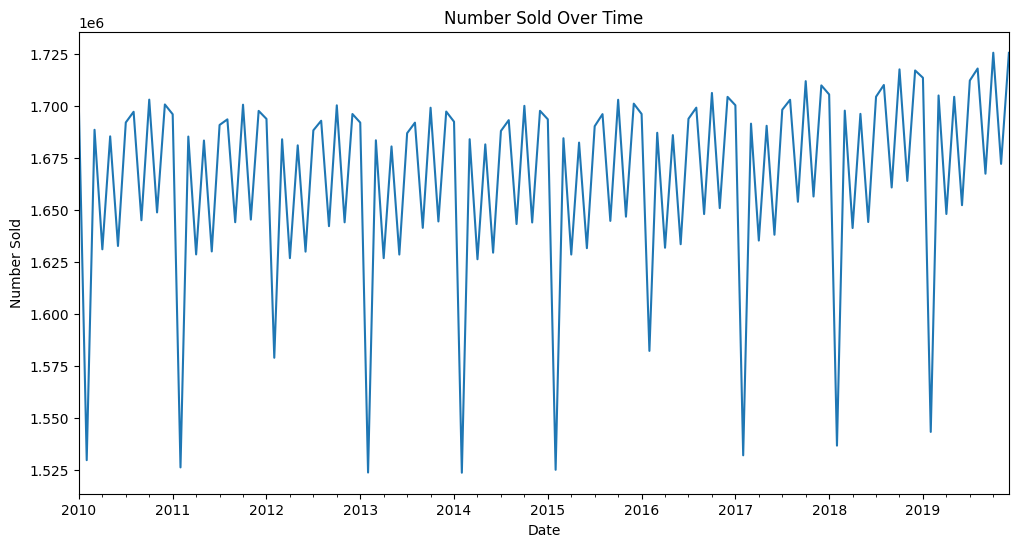

In [ ]:
df['number_sold'].resample('M').sum().plot(figsize=(12, 6), title='Number Sold Over Time', xlabel='Date', ylabel='Number Sold')

In [24]:
df_train = df[['number_sold']].resample('M').sum()

C:\Users\rodri\AppData\Local\Temp\ipykernel_20716\1725263537.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_train = df[['number_sold']].resample('M').sum()


In [17]:
!pip install mlforecast

   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ------------------------------- -------- 12.3/15.8 MB 64.1 MB/s eta 0:00:01
   ---------------------------------------- 15.8/15.8 MB 52.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.0
    Uninstalling numpy-2.0.0:
      Successfully uninstalled numpy-2.0.0


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 0.0.266 requires pydantic<2,>=1, but you have pydantic 2.11.1 which is incompatible.
streamlit 1.44.0 requires packaging<25,>=20, but you have packaging 25.0 which is incompatible.
tensorflow-intel 2.12.0 requires numpy<1.24,>=1.22, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
pip freeze numpy

absl-py==1.4.0
accelerate==1.4.0
aiohttp==3.8.4
aiosignal==1.3.1
altair==4.2.2
annotated-types==0.7.0
anyio==4.9.0
appdirs==1.4.4
apriori-python==1.0.4
argon2-cffi==21.3.0
argon2-cffi-bindings==21.2.0
arrow==1.2.3
arviz==0.21.0
asttokens==2.2.1
astunparse==1.6.3
async-generator==1.10
async-timeout==4.0.2
attrs==23.2.0
autograd==1.6.2
autograd-gamma==0.5.0
Babel==2.11.0
backcall==0.2.0
beautifulsoup4==4.11.1
binaryornot==0.4.4
bitsandbytes==0.45.3
bleach==5.0.1
blinker==1.5
boto3==1.28.21
botocore==1.31.21
browser-cookie3==0.19.1
bs4==0.0.1
CacheControl==0.12.11
cachetools==5.2.0
certifi==2022.12.7
cffi==1.15.1
chardet==5.1.0
charset-normalizer==2.1.1
click==7.1.2
colorama==0.4.4
comm==0.1.2
ConfigArgParse==1.7
contourpy==1.0.6
cookiecutter==2.1.1
cryptography==39.0.1
cs-dlp @ file:///C:/Users/rodri/Downloads/cs-dlp
cut-cross-entropy==25.1.1
cycler==0.11.0
Cython==0.29.33
dataclasses-json==0.5.14
datasets==3.3.2
dates==0.0.1
debugpy==1.6.4
decorator==5.1.1
defusedxml==0.7.1
diffusers==0

In [28]:
from mlforecast import MLForecast
from xgboost import XGBRegressor

df_train_reset = df_train.reset_index().rename(columns={'Date': 'ds', 'number_sold': 'y'})
df_train_reset['unique_id'] = '1'

# Create and fit the MLForecast pipeline with XGBoost
mlf = MLForecast(
    models=[XGBRegressor()],
    freq='M',
    lags=[1, 7, 30],
    date_features=['month', 'dayofweek']
)
mlf.fit(df_train_reset)

ImportError: Numba needs NumPy 1.26 or less